## Time Series Prediction and Benchmarking with CPU vs GPU-Accelerated scikit-learn Models
**Delegate**: Jiao Chi  
**Mail**: Chijiao2018@163.com

#### Project objectives: 
1. Build and benchmark time series prediction models using CPU-based scikit-learn algorithms. 
2. Re-implement the same models with same data using accelerated GPU version.
3. Compare the results and draw conclusions on training, inference time and predictive accuracy.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import f1_score, accuracy_score
import cudf
import cupy as cp
from cuml.ensemble import RandomForestClassifier as cuRF
from cuml.linear_model import LogisticRegression as cuLogisticRegression
from cuml.svm import SVC as cuSVC
from cuml.metrics import accuracy_score, precision_score, recall_score
import time

# 
gdf = cudf.DataFrame.from_pandas(df)
X_gpu = cupy.asarray(X_numpy)

ModuleNotFoundError: No module named 'cudf'

## 1. Achieve and clean data
The dataset was firstly imported and processed to generate features and label.

In [2]:
raw = pd.read_csv('https://certificate.tpq.io/eoddata.csv', parse_dates=True, index_col=0)
raw.head()

,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,.STOXXE,.V2TX,SPY,EUR=,XAU=,GDX,GLD,BTC=
Date,,,,,,,,,,,,,
2014-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.3752,1205.29,NaN,NaN,NaN
2014-01-02,19.754623,37.16,25.790,19.8985,176.89,310.44,18.9286,182.920,1.3670,1224.51,22.03,118.00,NaN
2014-01-03,19.320695,36.91,25.780,19.8220,178.15,312.08,18.0018,182.885,1.3587,1236.16,21.83,119.29,NaN
2014-01-06,19.426052,36.13,25.460,19.6815,179.37,311.82,18.1672,182.360,1.3627,1237.59,21.93,119.50,NaN
2014-01-07,19.287034,36.41,25.585,19.9015,178.29,315.30,17.1932,183.480,1.3615,1231.49,21.97,118.82,NaN


In [3]:
df = raw.copy().dropna()
df

,AAPL.O,MSFT.O,INTC.O,AMZN.O,GS.N,.STOXXE,.V2TX,SPY,EUR=,XAU=,GDX,GLD,BTC=
Date,,,,,,,,,,,,,
2016-11-14,26.4275,58.12,34.48,35.9535,209.18,324.28,22.1941,216.59,1.0734,1219.86,21.12,116.11,703.82
2016-11-15,26.7775,58.87,34.91,37.1620,211.19,325.75,20.6381,218.28,1.0720,1227.98,22.02,117.12,711.06
2016-11-16,27.4975,59.65,34.84,37.3245,206.26,324.00,21.1147,217.87,1.0685,1224.90,21.84,116.77,739.70
2016-11-17,27.4875,60.64,35.02,37.8200,209.63,325.53,19.9481,218.99,1.0625,1216.01,21.30,116.17,735.50
2016-11-18,27.5150,60.35,34.95,38.0080,210.35,323.96,20.3697,218.50,1.0585,1208.31,21.05,115.15,748.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-02-24,247.1000,404.00,24.27,212.7100,626.14,558.04,16.9490,597.21,1.0466,2951.19,40.97,272.21,93978.86
2025-02-25,247.0400,397.90,22.99,212.8000,614.91,557.62,17.7794,594.24,1.0513,2915.12,40.38,268.62,88680.81
2025-02-26,240.3600,399.73,23.52,214.3500,617.77,565.44,16.9863,594.54,1.0483,2916.19,40.86,269.03,84454.71


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2055 entries, 2016-11-14 to 2025-02-28
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   AAPL.O   2055 non-null   float64
 1   MSFT.O   2055 non-null   float64
 2   INTC.O   2055 non-null   float64
 3   AMZN.O   2055 non-null   float64
 4   GS.N     2055 non-null   float64
 5   .STOXXE  2055 non-null   float64
 6   .V2TX    2055 non-null   float64
 7   SPY      2055 non-null   float64
 8   EUR=     2055 non-null   float64
 9   XAU=     2055 non-null   float64
 10  GDX      2055 non-null   float64
 11  GLD      2055 non-null   float64
 12  BTC=     2055 non-null   float64
dtypes: float64(13)
memory usage: 224.8 KB


## 2. Create features and label 
The dataset was used to generate basic return-based and other features.
Labels were constructed using next-day return direction.
### 2.1 Calculate basic one-day return and log return



In [7]:
data = df.copy()
cols = df.columns
for col in cols:
        data[f'{col}_ret_1'] = data[col].pct_change()
        data[f'{col}_log_ret_1'] = np.log(data[col] / data[col].shift())  
data.columns

Index(['AAPL.O', 'MSFT.O', 'INTC.O', 'AMZN.O', 'GS.N', '.STOXXE', '.V2TX',
       'SPY', 'EUR=', 'XAU=', 'GDX', 'GLD', 'BTC=', 'AAPL.O_ret_1',
       'AAPL.O_log_ret_1', 'MSFT.O_ret_1', 'MSFT.O_log_ret_1', 'INTC.O_ret_1',
       'INTC.O_log_ret_1', 'AMZN.O_ret_1', 'AMZN.O_log_ret_1', 'GS.N_ret_1',
       'GS.N_log_ret_1', '.STOXXE_ret_1', '.STOXXE_log_ret_1', '.V2TX_ret_1',
       '.V2TX_log_ret_1', 'SPY_ret_1', 'SPY_log_ret_1', 'EUR=_ret_1',
       'EUR=_log_ret_1', 'XAU=_ret_1', 'XAU=_log_ret_1', 'GDX_ret_1',
       'GDX_log_ret_1', 'GLD_ret_1', 'GLD_log_ret_1', 'BTC=_ret_1',
       'BTC=_log_ret_1'],
      dtype='object')

### 2.2 Add more features to data

In [8]:
# Initiate a empty dictionary to collect features in the column loop.
new_features = {}


# Momentum and volatility features
for col in cols:
    for i in [5, 10, 20]:
        new_features[f'{col}_mom_{i}'] = data[col] / data[col].shift(i) - 1
        new_features[f'{col}_vol_{i}'] = data[f'{col}_log_ret_1'].rolling(i).std()
    
# Lagged return features    
    for i in range(1,6):
        data[f'{col}_ret_lag_{i}'] = data[f'{col}_ret_1'].shift(i)


    new_features[f'{col}_skew_20'] = data[f'{col}_ret_1'].rolling(20).skew()
    new_features[f'{col}_kurt_20'] = data[f'{col}_ret_1'].rolling(20).kurt()
    new_features[f'{col}_min_20'] = data[col].rolling(20).min()
    new_features[f'{col}_max_20'] = data[col].rolling(20).max()
        
data = pd.concat([data, pd.DataFrame(new_features)], axis=1)


# Market and commpdity features
data['spy_ret'] = data['SPY'].pct_change()                   # Market return
data['spy_mom_10'] = data['SPY'] / data['SPY'].shift(10) - 1   # Market momentum factor
data['vix_change'] = data['.V2TX'].pct_change()              # Volatility change
data['vix_vol'] = data['.V2TX'].rolling(10).std()            # Rolling volatility change
data['gold_ret'] = data['XAU='].pct_change()                 # Commodity price change
data['btc_ret'] = data['BTC='].pct_change()                  # Bitcoin price change
data['gold_spy_ratio'] = data['XAU='] / data['SPY']            # Gold-to-market ratio
data['btc_spy_ratio'] = data['BTC='] / data['SPY']             # Bitcoin-to-market ratio


data.dropna(inplace=True)
print(data.head())
data.columns

             AAPL.O  MSFT.O  INTC.O   AMZN.O    GS.N  .STOXXE    .V2TX  \
Date                                                                     
2016-12-13  28.7975   62.98   36.80  38.7170  238.55   345.23  16.8704   
2016-12-14  28.7975   62.68   36.55  38.4410  239.93   342.84  17.1147   
2016-12-15  28.9550   62.58   36.79  38.0500  243.00   346.50  15.8633   
2016-12-16  28.9925   62.30   36.31  37.8885  238.90   347.57  15.0980   
2016-12-19  29.1600   63.62   36.89  38.3000  239.07   347.53  15.1177   

               SPY    EUR=     XAU=  ...  BTC=_min_20  BTC=_max_20   spy_ret  \
Date                                 ...                                       
2016-12-13  227.76  1.0625  1157.96  ...       711.06       777.11  0.006674   
2016-12-14  225.88  1.0535  1144.12  ...       729.46       777.11 -0.008254   
2016-12-15  226.81  1.0412  1128.34  ...       729.46       777.11  0.004117   
2016-12-16  225.04  1.0447  1133.99  ...       729.46       781.32 -0.007804   
2

Index(['AAPL.O', 'MSFT.O', 'INTC.O', 'AMZN.O', 'GS.N', '.STOXXE', '.V2TX',
       'SPY', 'EUR=', 'XAU=',
       ...
       'BTC=_min_20', 'BTC=_max_20', 'spy_ret', 'spy_mom_10', 'vix_change',
       'vix_vol', 'gold_ret', 'btc_ret', 'gold_spy_ratio', 'btc_spy_ratio'],
      dtype='object', length=242)

### 2.3 Construct labels

In [9]:
for col in cols:
    data['target'] = (df[col].pct_change().shift(-1) > 0).astype(int)
data.head()
feature_data = data.drop(columns=['target'])
target_data = data['target']
feature_data.shape, target_data.shape

((2035, 242), (2035,))

## 3. Data partitioning
The dataset is split chronologically into training and testing sets to preserve temporal order and avoid look-ahead bias.

In [ ]:
# Split 70% data for training, 30% data for testing.
train_size = int(len(feature_data) * 0.7)

In [11]:
x_train, y_train = feature_data.iloc[:train_size], target_data.iloc[:train_size]
x_test, y_test = feature_data.iloc[train_size:], target_data.iloc[train_size:]

x_train.shape, y_train.shape, x_test.shape, y_test.shape

((1424, 242), (1424,), (611, 242), (611,))

In [48]:
x_train_gpu = cudf.DataFrame.from_pandas(x_train)
x_test_gpu  = cudf.DataFrame.from_pandas(x_test)
y_train_gpu = cudf.Series(y_train)
y_test_gpu  = cudf.Series(y_test)

NameError: name 'cudf' is not defined

## 4. Feature scaling
Eliminating the bias caused by differing feature scales. Accelerating the convergence of gradient descent-based models. Ensuring all features contribute proportionally to the model’s learning process, rather than letting large-scale features overshadow smaller ones. 


In [23]:
def robust_scaling(train_df, test_df):
    '''
    Applies Robust Scaling to ensure model convergence while mitigating outlier impact.
    Numerical Method: Uses Interquartile Range (IQR) for scaling instead of Variance.
    '''
    # Initialize RobustScaler
    scaler = RobustScaler()
    scaler.fit(train_df)
    
    # Transform all sets using training statistics
    train_s = scaler.transform(train_df)
    test_s = scaler.transform(test_df)
    
    train_scaled = pd.DataFrame(train_s, columns=train_df.columns, index=train_df.index)
    test_scaled = pd.DataFrame(test_s, columns=test_df.columns, index=test_df.index)


    avg_median = train_scaled.median().mean()
    print(f'Scaling Check: Training Median is {avg_median:.4f}')
    
    return train_scaled, test_scaled


train_scaled, test_scaled = robust_scaling(x_train, x_test)

Scaling Check: Training Median is 0.0000


## 5. Class rebalancing
Correcting model bias toward the majority class.

In [13]:
counts = y_train.value_counts()
c0 = counts.get(0, 0) 
c1 = counts.get(1, 0)
counts

target
1    751
0    673
Name: count, dtype: int64

percentage of class 0:47.26%; percentage of class 1: 52.74%


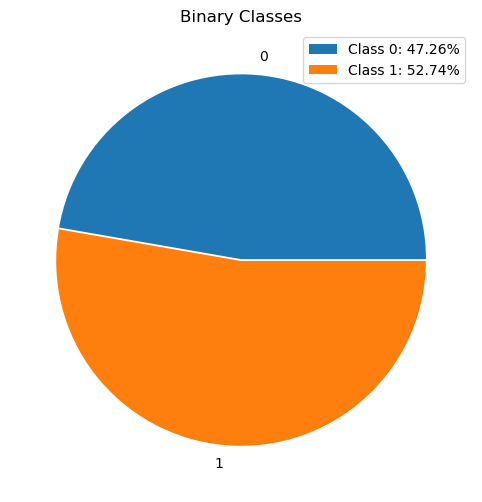

In [14]:
# Claculate the proportion of traing label.
pct_0 = round(c0/(c0+c1), 4)
pct_1 = round(c1/(c0+c1), 4)
print(f'percentage of class 0:{pct_0:.2%}; percentage of class 1: {pct_1:.2%}')

# Visulization the imbalance between classes.
plt.figure(figsize=(10,6))
plt.pie(
        [c0,c1],
        explode=(0.01, 0),
        labels=['0', '1']
        )
plt.title('Binary Classes')
plt.legend(
    labels=[f'Class 0: {pct_0:.2%}', f'Class 1: {pct_1:.2%}'],
)


#### There is no need for class rebalancing given the 47.26% / 52.74% class distribution.

## 6. Build models
### 6.1 Random forest

In [ ]:
# Random forest CPU version
rf_cpu = RandomForestClassifier(
    n_estimators=500, 
    max_depth=10, 
    random_state=42
)
# Random forest GPU version
rf_gpu = cuRF(
    n_estimators=500,
    max_depth=10,
    random_state=42
)

NameError: name 'cuRF' is not defined

### 6.2 XGBoost

In [ ]:
# XGBoost CPU version
xgb_cpu = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.05,
    
    # use partial features and samples to incease diversification
    colsample_bytree=0.5,  # use 50% features
    subsample=0.8,         # use 80% samples
    
    # use regularization to prevent from overfitting 
    reg_alpha=0.1,         # L1 regularization
    reg_lambda=1,          # L2 regularization
    
    random_state=42,
    eval_metric='logloss'
)

# XGBoost GPU version
xgb_gpu = XGBClassifier(
    n_estimator=500,
    max_depth=3,
    learning_rate=0.05,
    colsample_bytree=0.5,
    subsample=0.8,
    reg_alpha=0.1,
    reg_lambda=1,
    tree_method='gpu_hist',       # Start GPU
    predictor='gpu_predictor',   
    random_state=42,
    eval_metric='logloss'
)



### 6.3 SVM

In [ ]:
# SVM CPU version
svm_cpu = SVC(
    kernel='rbf',
    C=1, 
    gamma='scale',
    probability=False,        
    class_weight=None    
)

# SVM GPU version
svm_gpu = cuSVC(
    kernel='rbf',
    C=1,
    gamma='scale'
)


### 6.4 Logistic regression

In [ ]:
# Logistic regression CPU version
logit_cpu = LogisticRegression(
    penalty='l2',             # L2 regularization
    C=1,                    
    class_weight=None,
    random_state=42,
    max_iter=1000            
)

# Logistic regression GPU version
logit_gpu = cuLogisticRegression(
    penalty='l2',
    C=1,
    max_iter=1000
)



In [ ]:
model = ['rf_cpu', 'rf_gpu', 'xgb_cpu', 'xgb_gpu', 'svm_cpu', 'svm_gpu', 'logit_cpu', 'logit_gpu']

def compare(model, x_train, train_scaled, y_train, x_test, test_scaled, y_test, name='Model'):
    
    if 'logit' in name or 'svm' in name:
        # Training process
        start = time.perf_counter()
        model.fit(train_scaled, y_train)
        train_time = time.perf_counter() - start
        # Prediction
        start = time.perf_counter()
        y_pred = model.predict(test_scaled)
        pred_time = time.perf_counter() - start
        
    else:
        # Training process
        start = time.perf_counter()
        model.fit(x_train, y_train)
        train_time = time.perf_counter() - start
        # Prediction
        start = time.perf_counter()
        y_pred = model.predict(x_test)
        pred_time = time.perf_counter() - start
    
    # Evaluation 
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='binary')
    # Conclusion
    print(f'{name} | Train: {train_time:.4f}s | Predict: {pred_time:.4f}s | Accuracy: {acc:.4f} | F1 score: {f1:.4f}')
    return {
        'name': name,
        'train_time': train_time,
        'pred_time': pred_time,
        'accuracy': acc,
        'f1': f1
    }


In [ ]:
all_models = {
    'rf_cpu': rf_cpu,
    'rf_gpu': rf_gpu,
    'xgb_cpu': xgb_cpu,
    'xgb_gpu': xgb_gpu,
    'svm_cpu': svm_cpu,
    'svm_gpu': svm_gpu,
    'logit_cpu': logit_cpu,
    'logit_gpu': logit_gpu
}
results = []
for name, model in all_models.items():
    res = compare(model, x_train, train_scaled, y_train, x_test, test_scaled, y_test, name='Model')
    results.append(res)

def plot_compare_res(results):
    model_names = [r['name'] for r in results]
    train_times = [r['train_time'] for r in results]
    train_times = [r['train_time'] for r in results]
    train_times = [r['train_time'] for r in results]
    train_times = [r['train_time'] for r in results]
    
width = 0.3
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
x = np.arange(len(model_names)) 

# Subplot 1 
bar1 = ax1.bar(x - width/2, train_times, width, label='Training time', alpha=0.8)
bar2 = ax1.bar(x + width/2, pred_times, width, label='Prediction time', alpha=0.8)
ax1.set_title('Training & Prediction Time Comparison Across Models', fontsize=14, pad=15)  
ax1.set_xlabel('Model name', fontsize=12)
ax1.set_ylabel('time(s)', fontsize=12)
ax1.set_xticks(x)                                           
ax1.set_xticklabels(model_names, rotation=45, ha='right')    
ax1.legend(loc='upper right', fontsize=10)                  
ax1.bar_label(bar1, fmt='%.4f', padding=3, fontsize=8)
ax1.bar_label(bar2, fmt='%.4f', padding=3, fontsize=8)

# Subplot 2
bar3 = ax2.bar(x - width/2, accuracies, width, label='准确率', alpha=0.8)
bar4 = ax2.bar(x + width/2, f1_scores, width, label='F1值', alpha=0.8)
ax2.set_title('Accuracy & F1 Score Comparison Across Models', fontsize=14, pad=15)
ax2.set_xlabel('model names', fontsize=12)
ax2.set_ylabel('accuracies / f1 scores', fontsize=12)
ax2.set_xticks(x)
ax2.set_xticklabels(model_names, rotation=45, ha='right')
ax2.set_ylim(0, 1)  # 准确率/F1值限定0-1范围，更直观
ax2.legend(loc='lower right', fontsize=10)
ax2.grid(axis='y', alpha=0.3)
ax2.bar_label(bar3, fmt='%.4f', padding=3, fontsize=8)
ax2.bar_label(bar4, fmt='%.4f', padding=3, fontsize=8)

# 5. Display configuration
plt.tight_layout()
